In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from datetime import datetime

API_KEY    = "746a30f11c7a4614b7878680ed13a7e8"
UTC_OFFSET = 3  # Nairobi EAT

def get_anchor_hour_utc(dt):
    """
    10:00 AM NY in UTC.
    DST (Mar-Nov)  : NY=UTC-4 → 10AM = 14:00 UTC
    Standard (Nov-Mar): NY=UTC-5 → 10AM = 15:00 UTC
    """
    year  = dt.year

    # 2nd Sunday of March = DST start
    march_sundays = [d for d in range(1, 32)
                     if datetime(year, 3, d).weekday() == 6]
    dst_start = datetime(year, 3, march_sundays[1])

    # 1st Sunday of November = DST end
    nov_sundays = [d for d in range(1, 8)
                   if datetime(year, 11, d).weekday() == 6]
    dst_end = datetime(year, 11, nov_sundays[0])

    if dst_start <= dt.replace(tzinfo=None) < dst_end:
        return 14  # DST
    else:
        return 15  # Standard

def get_cutoff_hour_utc(dt):
    """12:00 PM NY = 2 hours after anchor."""
    return get_anchor_hour_utc(dt) + 2

# Test time references
print("Powell 10AM — Time Reference (Nairobi UTC+3)")
print("=" * 55)
test_dates = [
    datetime(2025, 12, 15),  # Standard Time
    datetime(2026, 3, 20),   # DST
    datetime(2026, 7, 10),   # DST (current)
]
for d in test_dates:
    a_utc = get_anchor_hour_utc(d)
    c_utc = get_cutoff_hour_utc(d)
    period = "DST" if a_utc == 14 else "Standard"
    print(f"  {str(d.date())} [{period:<8}] "
          f"Anchor: {a_utc:02d}:00 UTC = {a_utc+UTC_OFFSET:02d}:00 Nairobi | "
          f"Cutoff: {c_utc:02d}:00 UTC = {c_utc+UTC_OFFSET:02d}:00 Nairobi")
print("=" * 55)

Powell 10AM — Time Reference (Nairobi UTC+3)
  2025-12-15 [Standard] Anchor: 15:00 UTC = 18:00 Nairobi | Cutoff: 17:00 UTC = 20:00 Nairobi
  2026-03-20 [DST     ] Anchor: 14:00 UTC = 17:00 Nairobi | Cutoff: 16:00 UTC = 19:00 Nairobi
  2026-07-10 [DST     ] Anchor: 14:00 UTC = 17:00 Nairobi | Cutoff: 16:00 UTC = 19:00 Nairobi


In [2]:
def fetch_twelvedata(symbol="QQQ", interval="15min",
                     outputsize=5000):
    url    = "https://api.twelvedata.com/time_series"
    params = {
        "symbol"    : symbol,
        "interval"  : interval,
        "outputsize": outputsize,
        "apikey"    : API_KEY,
        "format"    : "JSON"
    }
    r    = requests.get(url, params=params)
    data = r.json()

    if data.get("status") == "error":
        print(f"Error: {data.get('message')}")
        return None

    df = pd.DataFrame(data["values"])
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.set_index("datetime").sort_index()
    df = df.astype(float)
    df.columns = [c.lower() for c in df.columns]
    return df

print("Fetching QQQ M15...")
df = fetch_twelvedata("QQQ", "15min", 5000)

if df is not None:
    print(f"Loaded  : {len(df)} bars")
    print(f"Range   : {df.index[0].date()} "
          f"to {df.index[-1].date()}")
    print(f"QQQ now : ${df['close'].iloc[-1]:.2f}")
    print(f"\nMarket hours check:")
    print(f"  First bar: {df.index[0]}")
    print(f"  Last bar : {df.index[-1]}")

Fetching QQQ M15...
Loaded  : 5000 bars
Range   : 2025-10-06 to 2026-07-15
QQQ now : $717.69

Market hours check:
  First bar: 2025-10-06 14:30:00
  Last bar : 2026-07-15 15:45:00


In [3]:
# Find all 10AM anchor bars
# Each trading day has exactly one 10AM candle
# UTC hour depends on DST period

anchors = []

# Get unique trading dates
trading_dates = df.index.normalize().unique()

for date in trading_dates:
    # Get correct anchor hour for this date
    dt         = date.to_pydatetime()
    anchor_utc = get_anchor_hour_utc(dt)
    cutoff_utc = get_cutoff_hour_utc(dt)

    # Find the 10AM bar for this date
    day_bars = df[df.index.date == date.date()]
    anchor_bars = day_bars[
        (day_bars.index.hour == anchor_utc) &
        (day_bars.index.minute == 0)
    ]

    if len(anchor_bars) == 0:
        continue  # market closed or missing data

    anchor_bar   = anchor_bars.iloc[0]
    anchor_price = anchor_bar['open']
    anchor_time  = anchor_bars.index[0]

    # Get all bars in the trading window
    # from 10AM to cutoff (12PM NY)
    window_bars = day_bars[
        (day_bars.index.hour >= anchor_utc) &
        (day_bars.index.hour < cutoff_utc)
    ]

    if len(window_bars) < 3:
        continue  # not enough bars

    anchors.append({
        'date'        : date.date(),
        'anchor_time' : anchor_time,
        'anchor_price': anchor_price,
        'anchor_utc'  : anchor_utc,
        'cutoff_utc'  : cutoff_utc,
        'anchor_local': anchor_utc + UTC_OFFSET,
        'cutoff_local': cutoff_utc + UTC_OFFSET,
        'window_bars' : window_bars
    })

print(f"10AM anchor bars found: {len(anchors)}")
print(f"Trading days in data  : {len(trading_dates)}")
print(f"\nSample anchors:")
for a in anchors[:3]:
    print(f"  {a['date']}  "
          f"Anchor: {a['anchor_utc']:02d}:00 UTC "
          f"= {a['anchor_local']:02d}:00 Nairobi  "
          f"Open: ${a['anchor_price']:.2f}")

10AM anchor bars found: 191
Trading days in data  : 194

Sample anchors:
  2025-10-07  Anchor: 14:00 UTC = 17:00 Nairobi  Open: $603.83
  2025-10-08  Anchor: 14:00 UTC = 17:00 Nairobi  Open: $610.02
  2025-10-09  Anchor: 14:00 UTC = 17:00 Nairobi  Open: $608.82


In [4]:
def detect_powell_setup(anchor, df):
    """
    Powell 10AM setup detection:
    1. Mark anchor price at 10AM open
    2. Detect manipulation — price sweeps above/below anchor
       within first 30 min (2 x M15 bars)
    3. Detect reversal — price closes back through anchor
    4. Entry on close back through anchor line
    5. SL behind manipulation wick extreme
    6. TP at 3R, 5R, 10R
    7. Cutoff at 12PM NY if not hit
    """
    anchor_price = anchor['anchor_price']
    anchor_time  = anchor['anchor_time']
    window_bars  = anchor['window_bars']
    cutoff_utc   = anchor['cutoff_utc']

    # Step 1 — Manipulation window (first 2 bars = 30 min)
    manip_bars = window_bars.iloc[:2]
    if len(manip_bars) == 0:
        return None

    manip_high = manip_bars['high'].max()
    manip_low  = manip_bars['low'].min()

    # Detect which way manipulation went
    swept_above = manip_high > anchor_price
    swept_below = manip_low  < anchor_price

    if not (swept_above or swept_below):
        return None  # no manipulation detected

    # Determine direction
    # If swept above = bearish setup (manipulation up, reverse down)
    # If swept below = bullish setup (manipulation down, reverse up)
    if swept_above and swept_below:
        # Both sides swept — take the larger sweep
        up_sweep   = manip_high - anchor_price
        down_sweep = anchor_price - manip_low
        if up_sweep >= down_sweep:
            direction = 'SHORT'
            manip_extreme = manip_high
        else:
            direction = 'LONG'
            manip_extreme = manip_low
    elif swept_above:
        direction     = 'SHORT'
        manip_extreme = manip_high
    else:
        direction     = 'LONG'
        manip_extreme = manip_low

    # Step 2 — Look for reversal back through anchor
    entry_bar   = None
    entry_price = None

    remaining_bars = window_bars.iloc[1:]  # bars after first

    for idx, bar in remaining_bars.iterrows():
        if direction == 'SHORT':
            # Price was above anchor, look for close back below
            if bar['close'] < anchor_price:
                entry_bar   = idx
                entry_price = bar['close']
                break
        else:
            # Price was below anchor, look for close back above
            if bar['close'] > anchor_price:
                entry_bar   = idx
                entry_price = bar['close']
                break

    if entry_price is None:
        return None  # no reversal through anchor

    # Step 3 — SL behind manipulation extreme
    risk = abs(entry_price - manip_extreme)
    if risk == 0:
        return None

    if direction == 'SHORT':
        sl = manip_extreme  # above entry
    else:
        sl = manip_extreme  # below entry

    # Step 4 — TP levels
    tp3  = entry_price - 3*risk  if direction=='SHORT' \
           else entry_price + 3*risk
    tp5  = entry_price - 5*risk  if direction=='SHORT' \
           else entry_price + 5*risk
    tp10 = entry_price - 10*risk if direction=='SHORT' \
           else entry_price + 10*risk

    return {
        'direction'    : direction,
        'anchor_price' : anchor_price,
        'manip_extreme': manip_extreme,
        'entry_price'  : entry_price,
        'entry_bar'    : entry_bar,
        'sl'           : sl,
        'tp3'          : tp3,
        'tp5'          : tp5,
        'tp10'         : tp10,
        'risk'         : risk,
    }

# Detect setups on all anchor days
setups = []
for anchor in anchors:
    setup = detect_powell_setup(anchor, df)
    if setup:
        setup['date'] = anchor['date']
        setups.append(setup)

print(f"Powell setups detected  : {len(setups)}")
print(f"Anchor days             : {len(anchors)}")
print(f"Setup rate              : {len(setups)/len(anchors):.0%}")
print(f"\nDirection breakdown:")
longs  = sum(1 for s in setups if s['direction']=='LONG')
shorts = sum(1 for s in setups if s['direction']=='SHORT')
print(f"  LONG  : {longs}")
print(f"  SHORT : {shorts}")

Powell setups detected  : 87
Anchor days             : 191
Setup rate              : 46%

Direction breakdown:
  LONG  : 45
  SHORT : 42


In [5]:
def simulate_exit(setup, df):
    """
    Simulate trade exit after entry.
    Test 3R, 5R, 10R targets and time cutoff.
    """
    direction   = setup['direction']
    entry_price = setup['entry_price']
    entry_bar   = setup['entry_bar']
    sl          = setup['sl']
    tp3         = setup['tp3']
    tp5         = setup['tp5']
    tp10        = setup['tp10']
    risk        = setup['risk']

    # Get bars after entry until end of day
    date       = setup['date']
    day_bars   = df[df.index.date == date]
    entry_idx  = day_bars.index.get_loc(entry_bar)
    post_entry = day_bars.iloc[entry_idx+1:]

    # Track outcomes for each TP level
    outcomes = {'3R': None, '5R': None, '10R': None}
    hit_sl   = False

    for idx, bar in post_entry.iterrows():
        # Check SL first
        if direction == 'SHORT':
            if bar['high'] >= sl:
                hit_sl = True
                break
            if outcomes['3R']  is None and bar['low'] <= tp3:
                outcomes['3R']  = 3.0
            if outcomes['5R']  is None and bar['low'] <= tp5:
                outcomes['5R']  = 5.0
            if outcomes['10R'] is None and bar['low'] <= tp10:
                outcomes['10R'] = 10.0
        else:
            if bar['low'] <= sl:
                hit_sl = True
                break
            if outcomes['3R']  is None and bar['high'] >= tp3:
                outcomes['3R']  = 3.0
            if outcomes['5R']  is None and bar['high'] >= tp5:
                outcomes['5R']  = 5.0
            if outcomes['10R'] is None and bar['high'] >= tp10:
                outcomes['10R'] = 10.0

    # Fill unresolved outcomes
    for tp_label in ['3R', '5R', '10R']:
        if outcomes[tp_label] is None:
            if hit_sl:
                outcomes[tp_label] = -1.0
            else:
                # Time cutoff — partial close at last bar
                last_bar = post_entry.iloc[-1] \
                           if len(post_entry) > 0 else None
                if last_bar is not None:
                    if direction == 'SHORT':
                        pnl = (entry_price - \
                               last_bar['close']) / risk
                    else:
                        pnl = (last_bar['close'] - \
                               entry_price) / risk
                    outcomes[tp_label] = round(pnl, 2)
                else:
                    outcomes[tp_label] = 0.0

    return outcomes, hit_sl

# Simulate all setups
results = []
for setup in setups:
    outcomes, hit_sl = simulate_exit(setup, df)
    results.append({
        'date'         : setup['date'],
        'direction'    : setup['direction'],
        'entry'        : round(setup['entry_price'], 2),
        'sl'           : round(setup['sl'], 2),
        'risk'         : round(setup['risk'], 2),
        'anchor'       : round(setup['anchor_price'], 2),
        'manip_extreme': round(setup['manip_extreme'], 2),
        'hit_sl'       : hit_sl,
        'r_3R'         : outcomes['3R'],
        'r_5R'         : outcomes['5R'],
        'r_10R'        : outcomes['10R'],
    })

results_df = pd.DataFrame(results)

# Quick summary
print(f"Simulated : {len(results_df)} trades")
print(f"Stop outs : {results_df['hit_sl'].sum()}")
print(f"Stop rate : {results_df['hit_sl'].mean():.0%}")
print(f"\nSample results:")
print(results_df[['date','direction','entry',
                   'sl','risk','r_3R','r_5R',
                   'r_10R']].head(5).to_string(index=False))

Simulated : 87 trades
Stop outs : 32
Stop rate : 37%

Sample results:
      date direction  entry     sl  risk  r_3R  r_5R  r_10R
2025-10-08     SHORT 609.96 610.59  0.63 -1.00 -1.00  -1.00
2025-10-09      LONG 608.88 608.05  0.83  2.20  2.20   2.20
2025-10-13     SHORT 601.95 602.73  0.78 -0.12 -0.12  -0.12
2025-10-14     SHORT 601.41 602.11  0.70 -1.00 -1.00  -1.00
2025-10-15      LONG 602.22 600.62  1.60 -1.00 -1.00  -1.00


In [6]:
def analyse_powell(results_df, tp_label='r_3R'):
    r = results_df[tp_label].astype(float)
    wins   = (r > 0).sum()
    losses = (r <= -1.0).sum()
    total  = len(r)
    wr     = wins / total
    avg_w  = r[r > 0].mean()
    avg_l  = r[r < 0].mean()
    exp    = (wr * avg_w) + ((1-wr) * abs(avg_l)) \
             if avg_l != 0 else wr * avg_w
    exp    = (wr * avg_w) + ((1-wr) * avg_l)
    tot_r  = r.sum()
    return {"wr": wr, "avg_w": avg_w, "avg_l": avg_l,
            "exp": exp, "total_r": tot_r, "n": total}

print(f"\n{'='*65}")
print(f"  POWELL 10AM STRATEGY — QQQ M15 BACKTEST RESULTS")
print(f"{'='*65}")
print(f"  Period    : Oct 2025 - Jul 2026 (9 months)")
print(f"  Setups    : 87 / 191 trading days (46%)")
print(f"  Stop rate : {results_df['hit_sl'].mean():.0%}")
print(f"{'='*65}")
print(f"\n  {'Target':<10} {'N':>4} {'WR':>6} "
      f"{'Avg W':>8} {'Avg L':>8} "
      f"{'Exp':>8} {'Total R':>9}")
print(f"  {'-'*60}")

for label in ['r_3R', 'r_5R', 'r_10R']:
    m   = analyse_powell(results_df, label)
    lbl = label.replace('r_', '')
    print(f"  {lbl:<10} {m['n']:>4} {m['wr']:>6.0%} "
          f"{m['avg_w']:>8.2f} {m['avg_l']:>8.2f} "
          f"{m['exp']:>8.3f} {m['total_r']:>8.1f}R")

print(f"{'='*65}")

# Direction breakdown
print(f"\n  BY DIRECTION (3R target):")
print(f"  {'-'*55}")
for d in ['LONG', 'SHORT']:
    sub = results_df[results_df['direction']==d]
    m   = analyse_powell(sub, 'r_3R')
    print(f"  {d:<8} n:{m['n']:>3}  WR:{m['wr']:>5.0%}  "
          f"Exp:{m['exp']:>7.3f}  "
          f"Total:{m['total_r']:>7.1f}R")

# Monthly breakdown
print(f"\n  BY MONTH (3R target):")
print(f"  {'-'*55}")
results_df['month'] = pd.to_datetime(
    results_df['date']).dt.strftime('%Y-%m')
for month in sorted(results_df['month'].unique()):
    sub = results_df[results_df['month']==month]
    m   = analyse_powell(sub, 'r_3R')
    print(f"  {month}  n:{m['n']:>3}  WR:{m['wr']:>5.0%}  "
          f"Exp:{m['exp']:>7.3f}  "
          f"Total:{m['total_r']:>6.1f}R")


  POWELL 10AM STRATEGY — QQQ M15 BACKTEST RESULTS
  Period    : Oct 2025 - Jul 2026 (9 months)
  Setups    : 87 / 191 trading days (46%)
  Stop rate : 37%

  Target        N     WR    Avg W    Avg L      Exp   Total R
  ------------------------------------------------------------
  3R           87    33%     0.92    -0.82   -0.241    -11.1R
  5R           87    33%     0.89    -0.82   -0.252    -12.1R
  10R          87    33%     0.89    -0.82   -0.252    -12.1R

  BY DIRECTION (3R target):
  -------------------------------------------------------
  LONG     n: 45  WR:  40%  Exp: -0.135  Total:   -1.1R
  SHORT    n: 42  WR:  26%  Exp: -0.355  Total:  -10.0R

  BY MONTH (3R target):
  -------------------------------------------------------
  2025-10  n:  9  WR:  22%  Exp: -0.334  Total:  -2.1R
  2025-11  n:  6  WR:  50%  Exp: -0.310  Total:   0.1R
  2025-12  n:  8  WR:   0%  Exp:    nan  Total:  -4.3R
  2026-01  n:  9  WR:  33%  Exp: -0.479  Total:   0.7R
  2026-02  n:  7  WR:  43%  Ex

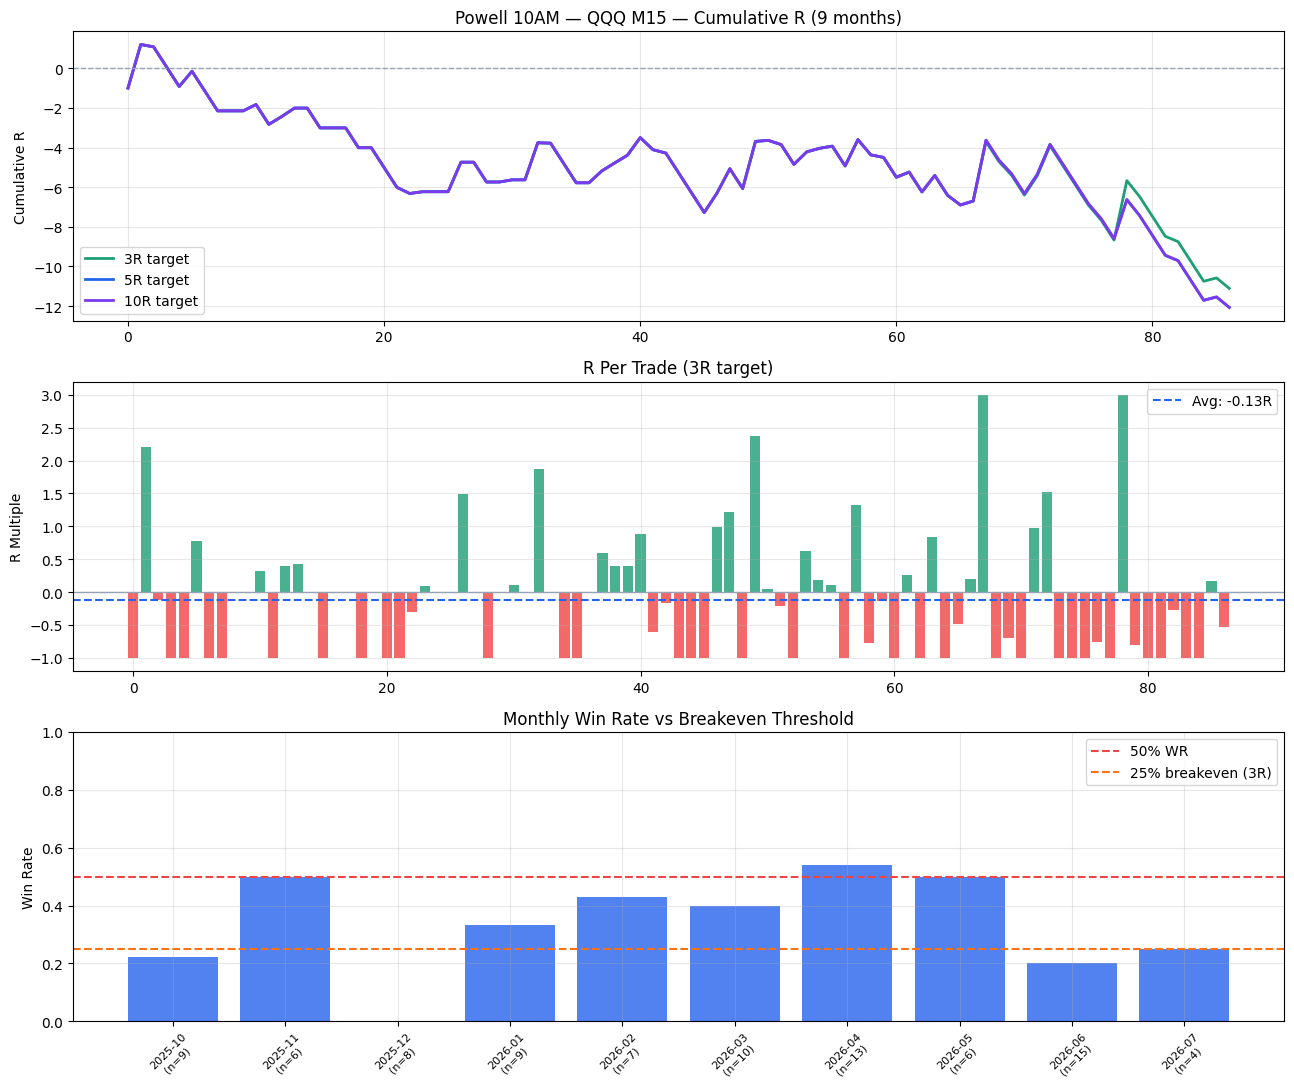

In [7]:
results_df = results_df.sort_values('date').reset_index(drop=True)
results_df['cum_r_3R']  = results_df['r_3R'].astype(float).cumsum()
results_df['cum_r_5R']  = results_df['r_5R'].astype(float).cumsum()
results_df['cum_r_10R'] = results_df['r_10R'].astype(float).cumsum()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 11))

# Panel 1: Cumulative R curves for all TP levels
x = np.arange(len(results_df), dtype=float)
ax1.plot(x, results_df['cum_r_3R'].values,
         color='#1D9E75', lw=2, label='3R target')
ax1.plot(x, results_df['cum_r_5R'].values,
         color='#2563eb', lw=2, label='5R target')
ax1.plot(x, results_df['cum_r_10R'].values,
         color='#7c3aed', lw=2, label='10R target')
ax1.axhline(0, color='#94a3b8', lw=1, linestyle='--')
ax1.set_title('Powell 10AM — QQQ M15 — Cumulative R (9 months)')
ax1.set_ylabel('Cumulative R')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: R per trade (3R target)
act_r     = results_df['r_3R'].astype(float).values
clr       = ['#1D9E75' if r > 0 else '#ef4444' for r in act_r]
ax2.bar(x, act_r, color=clr, alpha=0.8)
ax2.axhline(0, color='#94a3b8', lw=1)
ax2.axhline(act_r.mean(), color='#2563eb', lw=1.5,
            linestyle='--',
            label=f'Avg: {act_r.mean():+.2f}R')
ax2.set_title('R Per Trade (3R target)')
ax2.set_ylabel('R Multiple')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Monthly win rate
monthly   = results_df.groupby('month').apply(
    lambda x: (x['r_3R'] > 0).mean())
monthly_n = results_df.groupby('month').size()
ax3.bar(range(len(monthly)), monthly.values,
        color='#2563eb', alpha=0.8)
ax3.axhline(0.5, color='#ef4444', lw=1.5,
            linestyle='--', label='50% WR')
ax3.axhline(0.25, color='#f97316', lw=1.5,
            linestyle='--', label='25% breakeven (3R)')
ax3.set_xticks(range(len(monthly)))
ax3.set_xticklabels([f"{m}\n(n={n})"
    for m, n in zip(monthly.index, monthly_n.values)],
    fontsize=8, rotation=45)
ax3.set_title('Monthly Win Rate vs Breakeven Threshold')
ax3.set_ylabel('Win Rate')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
def backtest_filtered_powell(results_df, df,
                              min_manip_pct=0.002,
                              long_only=False,
                              tp_label='r_3R'):
    """
    Filter Powell setups by:
    min_manip_pct : minimum manipulation size
                    as % of price (default 0.2%)
    long_only     : only take LONG setups
    """
    filtered = results_df.copy()

    # Add manipulation size %
    filtered['manip_pct'] = abs(
        filtered['manip_extreme'] -
        filtered['anchor']) / filtered['anchor']

    # Apply filters
    if min_manip_pct:
        filtered = filtered[
            filtered['manip_pct'] >= min_manip_pct]

    if long_only:
        filtered = filtered[
            filtered['direction'] == 'LONG']

    if len(filtered) == 0:
        return None

    m = analyse_powell(filtered, tp_label)
    return m, len(filtered)

print(f"{'='*68}")
print(f"  POWELL FILTER TESTS — Finding the Edge")
print(f"{'='*68}")
print(f"  {'Filter':<35} {'N':>4} {'WR':>6} "
      f"{'Exp':>8} {'Total R':>9}")
print(f"  {'-'*63}")

tests = [
    ("Baseline (no filter)",
     0.000, False),
    ("Manip > 0.1%",
     0.001, False),
    ("Manip > 0.2%",
     0.002, False),
    ("Manip > 0.3%",
     0.003, False),
    ("Manip > 0.5%",
     0.005, False),
    ("LONG only",
     0.000, True),
    ("LONG only + Manip > 0.2%",
     0.002, True),
    ("LONG only + Manip > 0.3%",
     0.003, True),
    ("LONG only + Manip > 0.5%",
     0.005, True),
]

for name, min_m, lo in tests:
    result = backtest_filtered_powell(
        results_df, df, min_m, lo, 'r_3R')
    if result is None:
        print(f"  {name:<35} {'No signals':>30}")
        continue
    m, n = result
    print(f"  {name:<35} {n:>4} {m['wr']:>6.0%} "
          f"{m['exp']:>8.3f} {m['total_r']:>8.1f}R")

print(f"{'='*68}")

  POWELL FILTER TESTS — Finding the Edge
  Filter                                 N     WR      Exp   Total R
  ---------------------------------------------------------------
  Baseline (no filter)                  87    33%   -0.241    -11.1R
  Manip > 0.1%                          61    39%   -0.132     -0.5R
  Manip > 0.2%                          18    44%   -0.272     -4.1R
  Manip > 0.3%                          11    55%   -0.092     -0.3R
  Manip > 0.5%                           3    33%   -0.537     -1.6R
  LONG only                             45    40%   -0.135     -1.1R
  LONG only + Manip > 0.2%              13    62%   -0.112     -0.5R
  LONG only + Manip > 0.3%               9    67%   -0.052      0.5R
  LONG only + Manip > 0.5%               2    50%   -0.400     -0.8R


In [9]:
def backtest_extended_hold(setups, df,
                            min_manip_pct=0.003,
                            long_only=True,
                            max_bars_after=16,
                            tp_r=3.0):
    """
    Extended hold — let trades run past 12PM cutoff
    until TP or SL hit, max N bars after entry.
    """
    results = []

    for setup in setups:
        # Apply filters
        manip_pct = abs(setup['manip_extreme'] -
                        setup['anchor_price']) / \
                        setup['anchor_price']

        if manip_pct < min_manip_pct:
            continue
        if long_only and setup['direction'] != 'LONG':
            continue

        entry_price = setup['entry_price']
        entry_bar   = setup['entry_bar']
        sl          = setup['sl']
        risk        = setup['risk']
        direction   = setup['direction']

        if direction == 'LONG':
            tp = entry_price + tp_r * risk
        else:
            tp = entry_price - tp_r * risk

        # Get all bars from entry to max hold
        date      = setup['date']
        day_bars  = df[df.index.date == date]
        all_bars  = df[df.index >= entry_bar]
        hold_bars = all_bars.iloc[1:max_bars_after+1]

        outcome  = None
        actual_r = None

        for idx, bar in hold_bars.iterrows():
            if direction == 'LONG':
                if bar['low'] <= sl:
                    outcome  = 'LOSS'
                    actual_r = -1.0
                    break
                elif bar['high'] >= tp:
                    outcome  = 'WIN'
                    actual_r = tp_r
                    break
            else:
                if bar['high'] >= sl:
                    outcome  = 'LOSS'
                    actual_r = -1.0
                    break
                elif bar['low'] <= tp:
                    outcome  = 'WIN'
                    actual_r = tp_r
                    break

        if outcome is None:
            last = hold_bars.iloc[-1] \
                   if len(hold_bars) > 0 else None
            if last is not None:
                if direction == 'LONG':
                    actual_r = (last['close'] -
                                entry_price) / risk
                else:
                    actual_r = (entry_price -
                                last['close']) / risk
                outcome = 'TIME'
            else:
                actual_r = 0.0
                outcome  = 'TIME'

        results.append({
            'date'     : setup['date'],
            'direction': direction,
            'outcome'  : outcome,
            'actual_r' : round(float(actual_r), 3),
            'manip_pct': round(manip_pct*100, 3)
        })

    if not results:
        return None

    r_df   = pd.DataFrame(results)
    wins   = (r_df['outcome']=='WIN').sum()
    losses = (r_df['outcome']=='LOSS').sum()
    n      = len(r_df)
    wr     = wins / n
    avg_w  = r_df[r_df['actual_r']>0]['actual_r'].mean()
    avg_l  = r_df[r_df['actual_r']<0]['actual_r'].mean()
    exp    = (wr * avg_w) + ((1-wr) * avg_l) \
             if not pd.isna(avg_l) else wr * avg_w
    tot    = r_df['actual_r'].sum()

    return {"n": n, "wr": wr, "exp": exp,
            "total_r": tot, "wins": wins,
            "losses": losses, "r_df": r_df}

print(f"{'='*68}")
print(f"  EXTENDED HOLD TEST — LONG only + Manip > 0.3%")
print(f"{'='*68}")
print(f"  {'Hold (bars)':<15} {'N':>4} {'WR':>6} "
      f"{'Exp':>8} {'Total R':>9}")
print(f"  {'-'*55}")

for max_bars in [8, 12, 16, 20, 24, 32]:
    hours = max_bars * 15 / 60
    r = backtest_extended_hold(
        setups, df,
        min_manip_pct=0.003,
        long_only=True,
        max_bars_after=max_bars,
        tp_r=3.0)
    if r is None:
        continue
    print(f"  {max_bars} bars ({hours:.0f}hrs)    "
          f"{r['n']:>4} {r['wr']:>6.0%} "
          f"{r['exp']:>8.3f} {r['total_r']:>8.1f}R")

print(f"{'='*68}")

  EXTENDED HOLD TEST — LONG only + Manip > 0.3%
  Hold (bars)        N     WR      Exp   Total R
  -------------------------------------------------------
  8 bars (2hrs)       9    22%   -0.174      4.9R
  12 bars (3hrs)       9    33%    0.023      6.3R
  16 bars (4hrs)       9    33%   -0.002      6.0R
  20 bars (5hrs)       9    33%    0.026      6.4R
  24 bars (6hrs)       9    33%    0.099      7.5R
  32 bars (8hrs)       9    44%    0.581      8.8R


In [10]:
print(f"{'='*72}")
print(f"  COMBINED FILTER MATRIX — Finding Optimal Parameters")
print(f"{'='*72}")
print(f"  {'Filter':<30} {'Hold':>6} {'N':>4} {'WR':>6} "
      f"{'Exp':>8} {'Total R':>9}")
print(f"  {'-'*67}")

configs = [
    # (min_manip, long_only, max_bars, tp_r)
    (0.001, True,  32, 3.0),
    (0.002, True,  32, 3.0),
    (0.003, True,  32, 3.0),
    (0.001, True,  24, 3.0),
    (0.002, True,  24, 3.0),
    (0.001, False, 32, 3.0),
    (0.002, False, 32, 3.0),
    (0.001, True,  32, 5.0),
    (0.002, True,  32, 5.0),
    (0.001, True,  16, 3.0),
    (0.002, True,  16, 3.0),
]

best_exp  = -999
best_conf = None

for min_m, lo, mb, tp in configs:
    r = backtest_extended_hold(
        setups, df,
        min_manip_pct=min_m,
        long_only=lo,
        max_bars_after=mb,
        tp_r=tp)
    if r is None or r['n'] < 10:
        continue

    label = (f"Manip>{min_m*100:.1f}% "
             f"{'L' if lo else 'L+S'} "
             f"{mb}bars TP{tp:.0f}R")
    print(f"  {label:<30} {mb:>6} {r['n']:>4} "
          f"{r['wr']:>6.0%} {r['exp']:>8.3f} "
          f"{r['total_r']:>8.1f}R")

    if r['exp'] > best_exp:
        best_exp  = r['exp']
        best_conf = (min_m, lo, mb, tp, r)

print(f"{'='*72}")
if best_conf:
    min_m, lo, mb, tp, r = best_conf
    print(f"\n  BEST CONFIG:")
    print(f"  Manip > {min_m*100:.1f}% | "
          f"{'Long only' if lo else 'Long+Short'} | "
          f"Hold {mb} bars ({mb*15/60:.0f}hrs) | "
          f"TP {tp:.0f}R")
    print(f"  N={r['n']} | WR={r['wr']:.0%} | "
          f"Exp={r['exp']:.3f}R | "
          f"Total={r['total_r']:.1f}R")

  COMBINED FILTER MATRIX — Finding Optimal Parameters
  Filter                           Hold    N     WR      Exp   Total R
  -------------------------------------------------------------------
  Manip>0.1% L 32bars TP3R           32   34    26%    0.000      3.8R
  Manip>0.2% L 32bars TP3R           32   13    38%    0.397      8.8R
  Manip>0.1% L 24bars TP3R           24   34    24%   -0.141      2.5R
  Manip>0.2% L 24bars TP3R           24   13    31%    0.051      7.5R
  Manip>0.1% L+S 32bars TP3R         32   61    28%    0.088      9.3R
  Manip>0.2% L+S 32bars TP3R         32   18    28%    0.009      3.8R
  Manip>0.1% L 32bars TP5R           32   34    18%   -0.156     13.8R
  Manip>0.2% L 32bars TP5R           32   13    23%    0.083     15.2R
  Manip>0.1% L 16bars TP3R           16   34    24%   -0.177      1.0R
  Manip>0.2% L 16bars TP3R           16   13    31%   -0.027      6.0R

  BEST CONFIG:
  Manip > 0.2% | Long only | Hold 32 bars (8hrs) | TP 3R
  N=13 | WR=38% | Exp=